## Clustering the 2023 data with no preprocessing

### 1. Some data statistics

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
df = pd.read_csv('./../data/sample_23.csv')

# Exploring data
print("\nData info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Selecting numerical columns for clustering
numerical_columns = df.select_dtypes(include=[np.number]).columns
print(f"\nNumerical columns for clustering: {list(numerical_columns)}")

X = df[numerical_columns].values


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17547 entries, 0 to 17546
Columns: 366 entries, ID to 2023-12-31
dtypes: float64(365), int64(1)
memory usage: 49.0 MB
None

Summary statistics:
                  ID    2023-01-01    2023-01-02    2023-01-03    2023-01-04  \
count   17547.000000  17547.000000  17547.000000  17547.000000  17547.000000   
mean   153265.984898     10.924707     11.152843     11.045059     10.888636   
std     88233.186987     14.914385     13.773955     13.530065     13.217997   
min        22.000000      0.000000      0.000000      0.000000      0.000000   
25%     77002.500000      3.592500      3.605000      3.584500      3.635500   
50%    153934.000000      7.373000      7.365000      7.381000      7.258000   
75%    230109.000000     13.331500     13.381500     13.354000     13.081000   
max    304933.000000    997.388008    252.798000    234.426000    228.221000   

         2023-01-05    2023-01-06    2023-01-07    2023-01-08    2023-01-

### 2. Silhouette Analysis for detecting the number of clusters

#### 2.1. Load and Prepare Data

In [3]:
from matplotlib.dates import DateFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

df = pd.read_csv('./../data/sample_23.csv')

# Extract the IDs to keep them for later
ids = df['ID']

# Select only the date columns
date_columns = [col for col in df.columns if col != 'ID']
X = df[date_columns].fillna(0)  # Handle missing values

# Convert date strings to datetime objects for better plotting
try:
    dates = pd.to_datetime(date_columns)
except:
    dates = date_columns  # Fallback

#### 2.2. Silhouette Analysis to Find Optimal k

Performing Silhouette Analysis...
  Testing k=2...
  Testing k=3...
  Testing k=4...
  Testing k=5...
  Testing k=6...

Optimal number of clusters (k): 2
Silhouette Score for k=2: 0.664


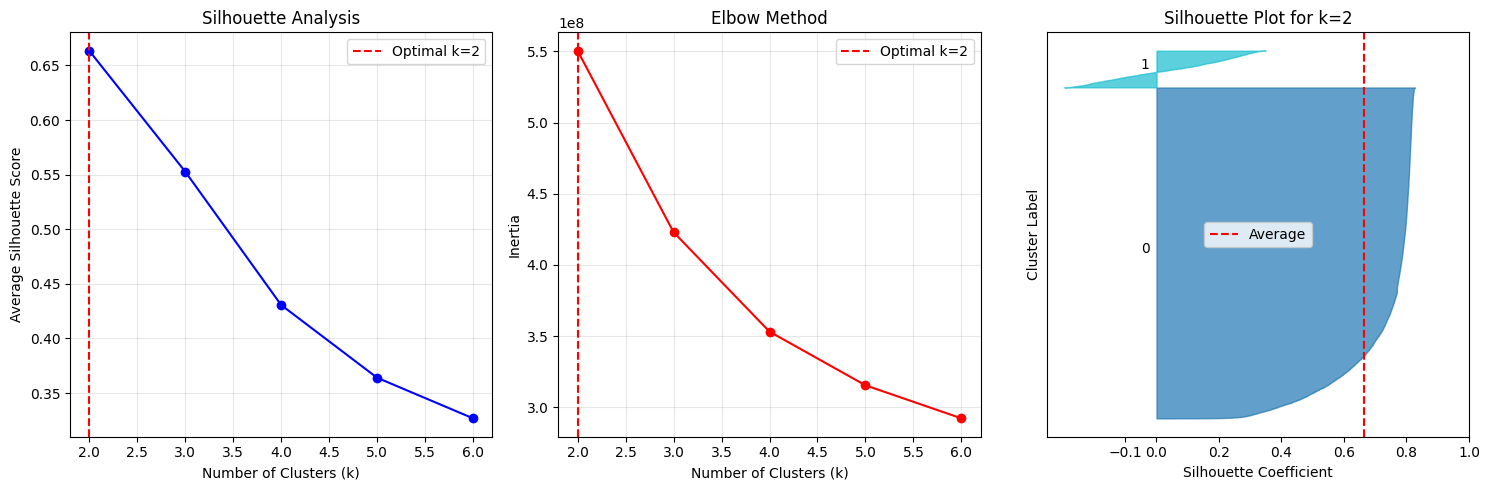

In [4]:
# Test different numbers of clusters
k_range = range(2, 7)
silhouette_avg = []
silhouette_per_k = []

print("Performing Silhouette Analysis...")
for k in k_range:
    print(f"  Testing k={k}...")
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    silhouette_avg_score = silhouette_score(X, cluster_labels)
    silhouette_avg.append(silhouette_avg_score)
    
    silhouette_per_k.append(silhouette_samples(X, cluster_labels))

# Find the optimal k (the one with the highest average silhouette score)
optimal_k = k_range[np.argmax(silhouette_avg)]
print(f"\nOptimal number of clusters (k): {optimal_k}")
print(f"Silhouette Score for k={optimal_k}: {max(silhouette_avg):.3f}")

# Plot the silhouette scores
plt.figure(figsize=(15, 5))

# Plot 1: Average Silhouette Score vs K
plt.subplot(1, 3, 1)
plt.plot(k_range, silhouette_avg, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.legend()

# Plot 2: Elbow Method (for comparison)
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.subplot(1, 3, 2)
plt.plot(k_range, inertias, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.legend()

# Plot 3: Detailed Silhouette Plot for the optimal k
plt.subplot(1, 3, 3)
k = optimal_k
silhouette_vals = silhouette_per_k[np.argmax(silhouette_avg)]
y_lower = 10

cluster_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
colors = cm.tab10(np.linspace(0, 1, k))

for i in range(k):
    ith_cluster_silhouette_values = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors[i]
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster Label')
plt.title(f'Silhouette Plot for k={k}')
plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--", label='Average')
plt.yticks([])
plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

#### 2.3. Apply K-Means With Optimal K

In [5]:
k = optimal_k  # Use the optimal k found by silhouette analysis

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters
centroids = kmeans.cluster_centers_

#### 2.4. Plot the Cluster Centroids

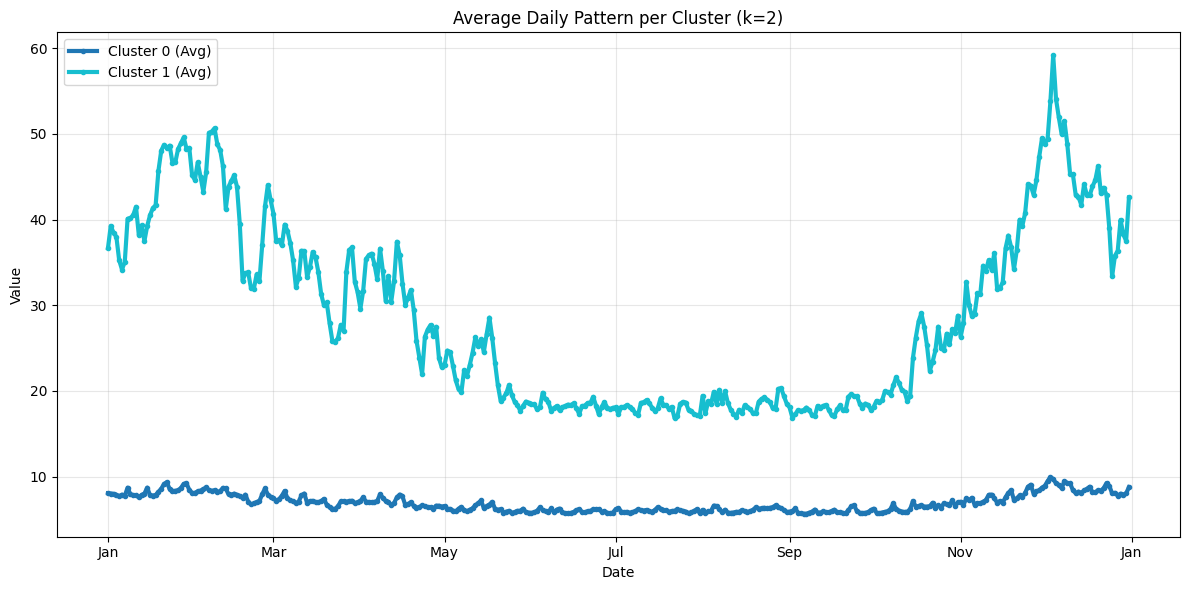

In [6]:
plt.figure(figsize=(12, 6))
colors = cm.tab10(np.linspace(0, 1, k))

for i in range(k):
    plt.plot(dates, centroids[i], label=f'Cluster {i} (Avg)', 
             color=colors[i], linewidth=3, marker='o', markersize=3)

plt.title(f'Average Daily Pattern per Cluster (k={k})')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(DateFormatter('%b'))
plt.tight_layout()
plt.show()

#### 2.5. Show Individual Members of Each Cluster

C:\Users\panai\AppData\Local\Temp\ipykernel_16464\1457281605.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\panai\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


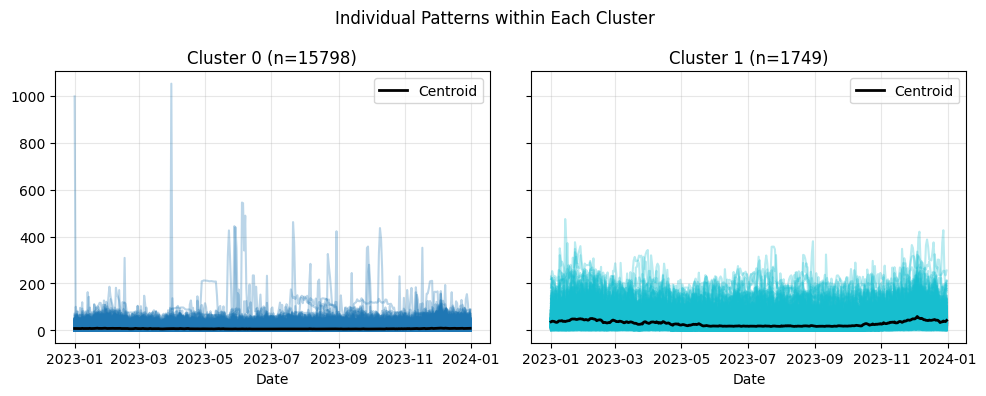

In [7]:
if k > 1:
    fig, axes = plt.subplots(1, k, figsize=(5*k, 4), sharey=True)
else:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    axes = [ax]

colors = cm.tab10(np.linspace(0, 1, k))

for cluster_id in range(k):
    ax = axes[cluster_id]
    cluster_members = df[df['Cluster'] == cluster_id]
    
    for idx, row in cluster_members.iterrows():
        ax.plot(dates, row[date_columns], color=colors[cluster_id], alpha=0.3)
    
    ax.plot(dates, centroids[cluster_id], color='black', linewidth=2, label='Centroid')
    ax.set_title(f'Cluster {cluster_id} (n={len(cluster_members)})')
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Individual Patterns within Each Cluster')
plt.tight_layout()
plt.show()

#### 2.6. Final Results

In [8]:
print("Final Cluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Silhouette Score: {max(silhouette_avg):.3f}")

Final Cluster Distribution:
Cluster
0    15798
1     1749
Name: count, dtype: int64

Optimal number of clusters: 2
Silhouette Score: 0.664
